<a href="https://colab.research.google.com/github/anishkr-sahu/revision_ml/blob/main/Revision_ml_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# logistic regression


In [19]:
# step -1 setup
import pandas as pd
import numpy as np

In [20]:
# data loading
df = pd.read_csv("/content/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
# step -2 data exploration
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [22]:
# Step 3: Feature engineering & cleaning
# Get the mean of Age from the DataFrame before column selection, in case selection makes it all NaN.
age_mean_val = df['Age'].mean()

# Feature selection
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()

# Cleaning - Fill missing values using direct assignment
df['Age'] = df['Age'].fillna(age_mean_val)
df['Embarked'] = df['Embarked'].fillna('S')

In [27]:
# encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
# multiple features
df = pd.get_dummies(df,columns=['Embarked'], drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [28]:
df.tail()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
886,0,2,1,27.000000,0,0,13.00,False,True
887,1,1,0,19.000000,0,0,30.00,False,True
888,0,3,0,29.699118,1,2,23.45,False,True
889,1,1,1,26.000000,0,0,30.00,False,False
890,0,3,1,32.000000,0,0,7.75,True,False


In [29]:
# step -4 define features (x) and target (y)
X = df.drop('Survived',axis=1)
Y = df['Survived']

X.shape
Y.shape

(891,)

In [30]:
# step -5 split data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


In [32]:
# step -6 feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [34]:
X_train_scaled
X_test_scaled

array([[ 0.81303367,  0.7243102 ,  0.01239022, ..., -0.33390078,
        -0.30335547, -1.68779402],
       [-0.40055118,  0.7243102 ,  0.11257046, ..., -0.42528387,
        -0.30335547,  0.59248936],
       [ 0.81303367,  0.7243102 , -0.73453348, ..., -0.47486697,
        -0.30335547,  0.59248936],
       ...,
       [ 0.81303367, -1.38062393,  0.6516366 , ..., -0.02308312,
        -0.30335547,  0.59248936],
       [-0.40055118, -1.38062393, -0.96556183, ..., -0.42528387,
        -0.30335547,  0.59248936],
       [ 0.81303367, -1.38062393, -1.96668467, ..., -0.30589933,
        -0.30335547,  0.59248936]])

In [35]:
# step -7 model training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter= 1000)
model.fit(X_train_scaled,Y_train)

LogisticRegression(max_iter=1000)

In [37]:
pred = model.predict(X_test_scaled)
print(pred[:20])
print(Y_test[:20].values)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0]
[1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0]


In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
cm = confusion_matrix(Y_test,pred)
acc = accuracy_score(Y_test,pred)
pr = precision_score(Y_test,pred)
re = recall_score(Y_test,pred)
f1 = f1_score(Y_test, pred)
cr = classification_report(Y_test,pred)
print("Confusion matrix: ",cm)
print("Accuracy: ",acc)
print("Precision: ",pr)
print("recall: ",re)
print("f1-score: ",f1)
print(cr)

Confusion matrix:  [[90 15]
 [19 55]]
Accuracy:  0.8100558659217877
Precision:  0.7857142857142857
recall:  0.7432432432432432
f1-score:  0.7638888888888888
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



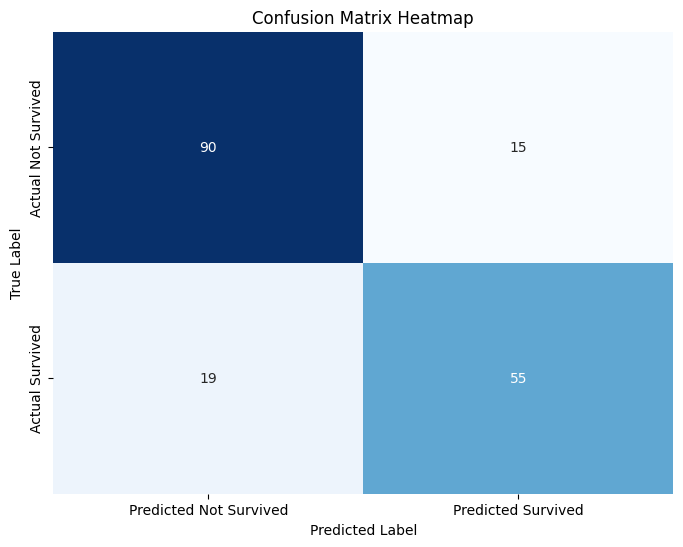

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Survived', 'Predicted Survived'],
            yticklabels=['Actual Not Survived', 'Actual Survived'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()